# Hyperparameter Grid Search

This notebook contains code to perform grid searches over hyperparameter combinations for the various training algorithms tested for this project

For each algorithm tested the hyperparameters explored are the following


##### PC
| Parameter | Role |
|-----------|------|
| `ci_test` | Conditional independence test (e.g. `"pearsonr"` for continuous Gaussian data, `"chi_square"` / `"g_sq"` for discrete) |
| `significance_level` | Alpha threshold, lower values yield sparser graphs (fewer edges kept after CI tests) |
| `max_cond_vars` | Maximum conditioning-set size, limits the depth of the skeleton-finding phase; `None` = no limit |

##### FGES
| Parameter | Role | Values |
|-----------|------|--------|
| `method` | BIC scoring variant | `scatter` (covariance-based), `r2` (adjusted R²) |

##### NOTEARS
| Parameter | Role |
|-----------|------|
| `lambda1` | L1 penalty, higher values push edge weights toward zero (sparser graphs) |
| `w_threshold` | Post-optimisation cutoff, edges with `\|weight\| < w_threshold` are pruned |

##### DAG-GNN
| Parameter | Role |
|-----------|------|
| `graph_threshold` | Post-training cutoff — edges with weight below this value are pruned (controls output sparsity) |
| `encoder_hidden` | Hidden-layer width of the VAE encoder — larger values increase model capacity |
| `epochs` | Number of training epochs — more epochs allow better convergence but increase runtime |

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
import logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from data import *
from reporting import plot_hyperparam_sensitivity, print_summary, METRIC_COLUMNS
from training import grid_search

logging.getLogger('castle').setLevel(logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42

/home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (
2026-07-04 13:58:31,361 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/backend/__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).
2026-07-04 13:58:31,382 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


In [2]:
def _marginal(results_df, param_grid, row_param, col_param):
    """Average metrics over all parameters except the given pair."""
    other = [p for p in param_grid if p not in (row_param, col_param)]
    return (
        results_df.groupby([row_param, col_param])[METRIC_COLUMNS].mean().reset_index()
        if other else results_df
    )


def plot_scatter(results_df, param_grid):
    """Precision–Recall scatter for all combinations.
    First two params drive color/marker; any extras are averaged out.
    Bubble size is proportional to SHD (smaller = better)."""
    param_names = list(param_grid.keys())
    p0, p1 = param_names[0], param_names[1]
    df     = _marginal(results_df, param_grid, p0, p1)
    p0_vals = sorted(df[p0].unique())
    p1_vals = sorted(df[p1].unique())
    colors  = plt.cm.tab10(np.linspace(0, 1, len(p0_vals)))
    markers = ["o", "s", "^", "D", "v", "P"]
    fig, ax = plt.subplots(figsize=(8, 6))
    for p0_idx, p0_val in enumerate(p0_vals):
        for _, row in df[df[p0] == p0_val].iterrows():
            p1_idx = p1_vals.index(row[p1])
            ax.scatter(row["precision"], row["recall"],
                       s=row["shd"] * 6 + 20,
                       color=colors[p0_idx],
                       marker=markers[p1_idx % len(markers)],
                       alpha=0.8, edgecolors="white", linewidths=0.5)
            ax.annotate(f"({p0_val},{row[p1]})",
                        (row["precision"], row["recall"]),
                        textcoords="offset points", xytext=(5, 3), fontsize=7, alpha=0.7)
    other = [p for p in param_names if p not in (p0, p1)]
    extra = f"  (avg over: {', '.join(other)})" if other else ""
    ax.set_title(f"Precision–Recall: {p0} × {p1}{extra}\n(bubble ∝ SHD)", fontsize=12)
    ax.set_xlabel("Precision"); ax.set_ylabel("Recall")
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color="grey", lw=0.5, ls="--")
    ax.axvline(0.5, color="grey", lw=0.5, ls="--")
    ax.grid(alpha=0.3)
    handles = [mpatches.Patch(color=colors[i], label=f"{p0}={v}") for i, v in enumerate(p0_vals)]
    ax.legend(handles=handles, title=p0, fontsize=8, loc="lower right")
    fig.tight_layout()
    plt.show()


def search_and_report(df, gt_dag, param_grid, algorithm: str):
    best_result, results_df = grid_search(df, algorithm, param_grid, gt_dag)
    best_params = results_df.loc[results_df["shd"].idxmin(), list(param_grid.keys())].to_dict()
    print(f"Best SHD: {results_df['shd'].min():.0f}  params: {best_params}")
    print(results_df)

    plot_hyperparam_sensitivity(results_df)
    # plot_scatter(results_df, param_grid)
    print_summary(results_df)


## Sachs et al.

This section of the notebook contains hyper-parameter search for the Sachs et al. protein dataset (11 variables)

In [5]:
sachs_df, sachs_dag  = load_sachs()
print(f"Sachs: {sachs_df.shape[0]} samples, {sachs_df.shape[1]} nodes, {len(sachs_dag.edges())} true edges")


Sachs: 11672 samples, 11 nodes, 20 true edges


### NOTEARS

In [33]:
SACHS_PARAM_GRID = {
    "lambda1":     [0.01, 0.05, 0.1, 0.2, 0.5],
    "w_threshold": [0.1, 0.2, 0.3, 0.5],
}

best_result_sachs, results_df_sachs = grid_search(sachs_df, "notears", SACHS_PARAM_GRID, sachs_dag)
best_params_sachs = results_df_sachs.loc[results_df_sachs["shd"].idxmin(), list(SACHS_PARAM_GRID.keys())].to_dict()
print(f"Best SHD: {results_df_sachs['shd'].min():.0f}  params: {best_params_sachs}")
results_df_sachs

2026-06-28 17:00:22,392 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=11672, d=11, iter_=100, h_=1e-08, rho_=10000000000000000


Grid: 5 × 4 = 20 combinations



2026-06-28 17:00:23,779 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=2.495e+00, loss=543643.397, rho=1.0e+00
2026-06-28 17:00:23,854 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.492e+00, loss=259284.164, rho=1.0e+00
2026-06-28 17:00:24,085 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.464e+00, loss=259312.179, rho=1.0e+01
2026-06-28 17:00:24,610 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.251e+00, loss=259592.326, rho=1.0e+02
2026-06-28 17:00:25,235 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradie

Best SHD: 20  params: {'lambda1': 0.01, 'w_threshold': 0.5}


,lambda1,w_threshold,n_learned,shd,precision,recall,f1,tp,fp,fn,reversed
0,0.01,0.1,27,26,0.259259,0.35,0.297872,7,13,6,7
1,0.01,0.2,19,22,0.315789,0.30,0.307692,6,8,9,5
2,0.01,0.3,18,22,0.333333,0.30,0.315789,6,8,10,4
3,0.01,0.5,13,20,0.384615,0.25,0.303030,5,5,12,3
4,0.05,0.1,24,26,0.250000,0.30,0.272727,6,12,8,6
5,0.05,0.2,19,22,0.315789,0.30,0.307692,6,8,9,5
6,0.05,0.3,18,22,0.333333,0.30,0.315789,6,8,10,4
7,0.05,0.5,12,20,0.416667,0.25,0.312500,5,5,13,2
8,0.10,0.1,24,26,0.250000,0.30,0.272727,6,12,8,6
9,0.10,0.2,19,22,0.315789,0.30,0.307692,6,8,9,5


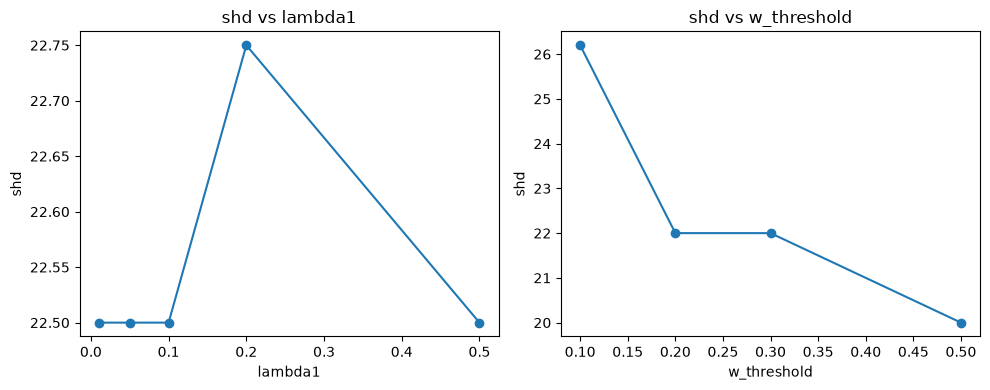

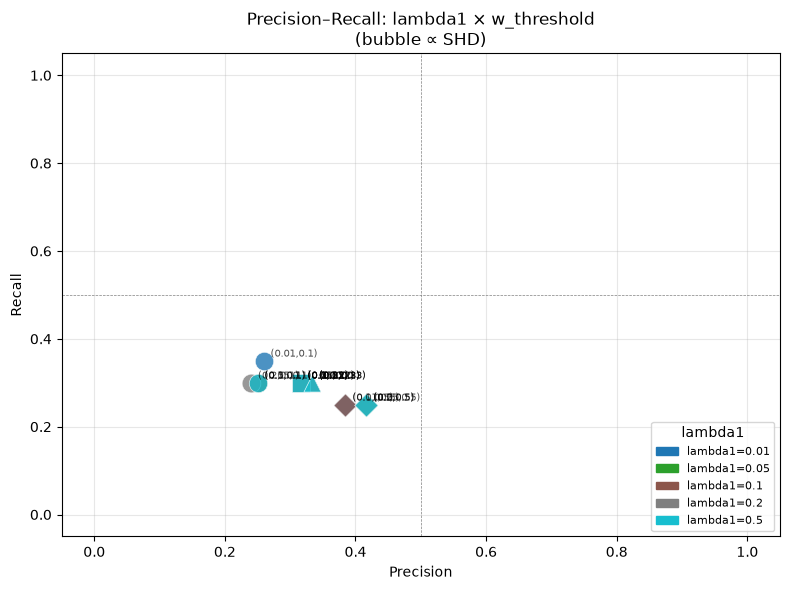

Top 5 combinations by shd
 lambda1  w_threshold    f1  precision  recall  shd  n_learned
    0.01          0.5 0.303      0.385    0.25   20         13
    0.05          0.5 0.312      0.417    0.25   20         12
    0.20          0.5 0.312      0.417    0.25   20         12
    0.10          0.5 0.303      0.385    0.25   20         13
    0.50          0.5 0.312      0.417    0.25   20         12

Recommended: lambda1=0.01, w_threshold=0.5
  F1=0.303  Precision=0.385  Recall=0.250  SHD=20


In [35]:
plot_hyperparam_sensitivity(results_df_sachs)
plot_scatter(results_df_sachs, SACHS_PARAM_GRID)
print_summary(results_df_sachs)


### PC

Grid: 1 × 6 × 4 = 24 combinations



2026-06-28 17:58:15,216 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-28 17:58:18,798 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-28 17:58:23,970 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-28 17:58:30,261 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-28 17:58:32,385 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discove

Best SHD: 30  params: {'ci_test': 'pearsonr', 'significance_level': 0.001, 'max_cond_vars': nan}
     ci_test  significance_level  max_cond_vars  n_learned  shd  precision  \
0   pearsonr               0.001            2.0         36   35   0.250000   
1   pearsonr               0.001            3.0         29   31   0.241379   
2   pearsonr               0.001            4.0         29   31   0.241379   
3   pearsonr               0.001            NaN         28   30   0.250000   
4   pearsonr               0.005            2.0         36   35   0.250000   
5   pearsonr               0.005            3.0         36   35   0.250000   
6   pearsonr               0.005            4.0         30   33   0.166667   
7   pearsonr               0.005            NaN         31   33   0.225806   
8   pearsonr               0.010            2.0         46   42   0.260870   
9   pearsonr               0.010            3.0         36   36   0.222222   
10  pearsonr               0.010            4

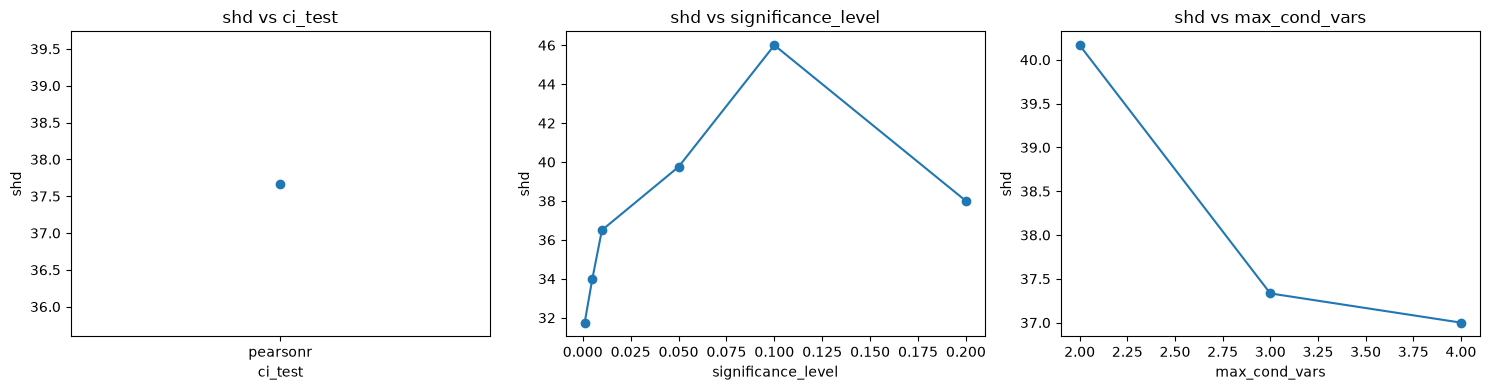

Top 5 combinations by shd
 ci_test  significance_level  max_cond_vars    f1  precision  recall  shd  n_learned
pearsonr               0.001            NaN 0.275      0.250   0.304   30         28
pearsonr               0.001            3.0 0.269      0.241   0.304   31         29
pearsonr               0.001            4.0 0.269      0.241   0.304   31         29
pearsonr               0.010            NaN 0.286      0.250   0.333   32         32
pearsonr               0.005            4.0 0.192      0.167   0.227   33         30

Recommended: ci_test=pearsonr, significance_level=0.001, max_cond_vars=nan
  F1=0.275  Precision=0.250  Recall=0.304  SHD=30


In [48]:
PC_PARAM_GRID = {
    "ci_test":            ["pearsonr"],
    "significance_level": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "max_cond_vars":      [2, 3, 4, None],
}
search_and_report(sachs_df, sachs_dag, PC_PARAM_GRID, "pc")

### FGES

In [43]:
FGES_SACHS_PARAM_GRID = {
    "method": ["scatter", "r2"],
}

best_result_fges_sachs, results_df_fges_sachs = grid_search(sachs_df, "fges", FGES_SACHS_PARAM_GRID, sachs_dag)
best_params_fges_sachs = results_df_fges_sachs.loc[
    results_df_fges_sachs["shd"].idxmin(), list(FGES_SACHS_PARAM_GRID.keys())
].to_dict()
print(f"Best SHD: {results_df_fges_sachs['shd'].min():.0f}  params: {best_params_fges_sachs}")
results_df_fges_sachs

Grid: 2 = 2 combinations

Best SHD: 26  params: {'method': 'r2'}


,method,n_learned,shd,precision,recall,f1,tp,fp,fn,reversed
0,scatter,35,33,0.228571,0.363636,0.280702,8,19,6,8
1,r2,20,26,0.363636,0.285714,0.320000,8,6,12,8


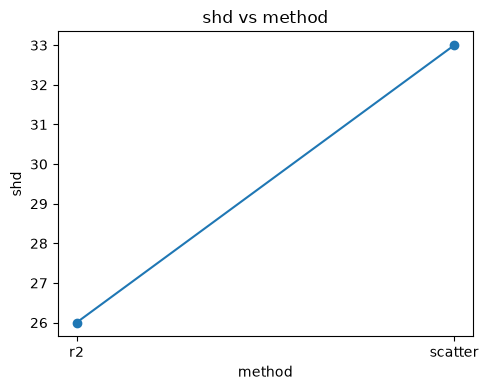

Top 5 combinations by shd
 method    f1  precision  recall  shd  n_learned
     r2 0.320      0.364   0.286   26         20
scatter 0.281      0.229   0.364   33         35

Recommended: method=r2
  F1=0.320  Precision=0.364  Recall=0.286  SHD=26


In [ ]:
plot_hyperparam_sensitivity(results_df_fges_sachs)
print_summary(results_df_fges_sachs)


### DAG-GNN

2026-06-30 21:41:42,383 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:165] - INFO: GPU is available.


Grid: 3 × 2 × 3 = 18 combinations



2026-06-30 21:42:36,294 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 0, epoch: 99, h_new: 2.0854441677082782
2026-06-30 21:45:16,270 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 1, epoch: 99, h_new: 0.18834909254875853
2026-06-30 21:47:04,819 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 2, epoch: 99, h_new: 0.030282866390908936
2026-06-30 21:48:52,264 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 3, epoch: 99, h_new: 0.007130835395567914
2026-06-30 21:50:39,955 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algo

Best SHD: 20  params: {'mlp_dimension': 32.0, 'epochs': 100.0, 'lr': 0.03}
    mlp_dimension  epochs      lr  n_learned  shd  precision  recall  \
0              32     100  0.0003         32   32   0.218750    0.35   
1              32     100  0.0030         27   27   0.285714    0.40   
2              32     100  0.0300          0   20   0.000000    0.00   
3              32     300  0.0003         34   31   0.228571    0.40   
4              32     300  0.0030         24   29   0.208333    0.25   
5              32     300  0.0300          0   20   0.000000    0.00   
6              64     100  0.0003         33   32   0.212121    0.35   
7              64     100  0.0030         27   27   0.285714    0.40   
8              64     100  0.0300          0   20   0.000000    0.00   
9              64     300  0.0003         31   31   0.225806    0.35   
10             64     300  0.0030         24   29   0.208333    0.25   
11             64     300  0.0300          0   20   0.000000 

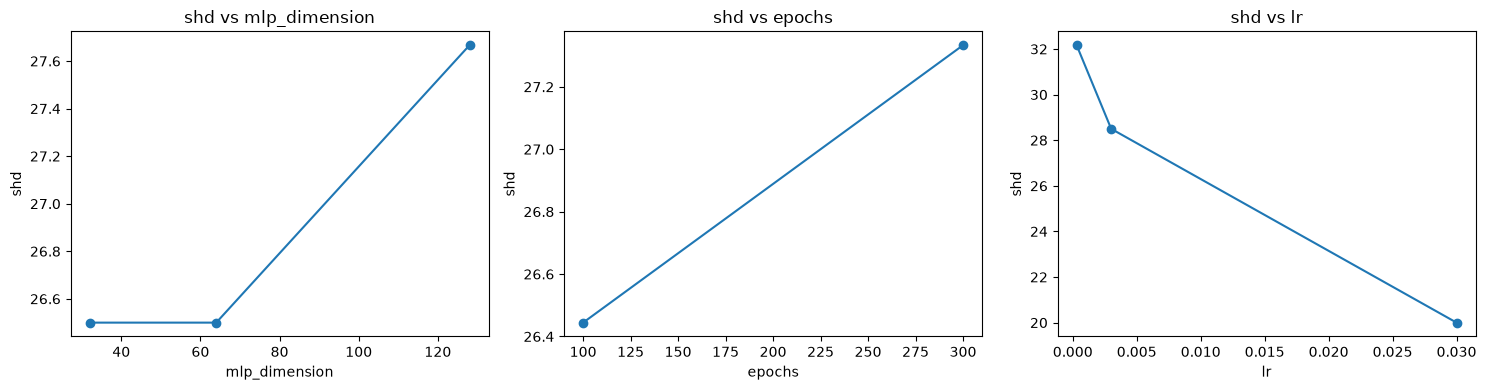

Top 5 combinations by shd
 mlp_dimension  epochs   lr  f1  precision  recall  shd  n_learned
            32     100 0.03 0.0        0.0     0.0   20          0
            32     300 0.03 0.0        0.0     0.0   20          0
            64     300 0.03 0.0        0.0     0.0   20          0
            64     100 0.03 0.0        0.0     0.0   20          0
           128     100 0.03 0.0        0.0     0.0   20          0

Recommended: mlp_dimension=32.0, epochs=100.0, lr=0.03
  F1=0.000  Precision=0.000  Recall=0.000  SHD=20


In [6]:
DAGGNN_SACHS_PARAM_GRID = {
    "mlp_dimension":  [32, 64, 128],
    "epochs":          [100, 300],
    "lr": [0.0003, 0.003, 0.03],
}
search_and_report(sachs_df, sachs_dag, DAGGNN_SACHS_PARAM_GRID, "daggnn")

## Cancer

This section of the notebook contains hyper-parameter search for the cancer dataset (5 variables)


In [3]:
cancer_df, cancer_dag = load_cancer(1000, SEED)
print(f"Cancer: {cancer_df.shape[0]} samples, {cancer_df.shape[1]} nodes, {len(cancer_dag.edges())} true edges")

Generating for node: Dyspnoea: 100%|██████████| 5/5 [00:00<00:00, 30.82it/s] 

Cancer: 1000 samples, 5 nodes, 4 true edges


### NOTEARS

2026-06-29 10:04:12,764 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=5, iter_=100, h_=1e-08, rho_=10000000000000000
2026-06-29 10:04:12,805 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=8.105e-07, loss=0.347, rho=1.0e+00
2026-06-29 10:04:12,808 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+00
2026-06-29 10:04:12,811 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+01
2026-06-29 10:04:12,813 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradie

Grid: 5 × 4 = 20 combinations



2026-06-29 10:04:12,967 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+00
2026-06-29 10:04:12,970 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+01
2026-06-29 10:04:12,973 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+02
2026-06-29 10:04:12,976 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+03
2026-06-29 10:04:12,979 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py

Best SHD: 3  params: {'lambda1': 0.01, 'w_threshold': 0.1}
    lambda1  w_threshold  n_learned  shd  precision  recall   f1  tp  fp  fn  \
0      0.01          0.1          1    3        1.0    0.25  0.4   1   0   3   
1      0.01          0.2          0    4        0.0    0.00  0.0   0   0   4   
2      0.01          0.3          0    4        0.0    0.00  0.0   0   0   4   
3      0.01          0.5          0    4        0.0    0.00  0.0   0   0   4   
4      0.05          0.1          0    4        0.0    0.00  0.0   0   0   4   
5      0.05          0.2          0    4        0.0    0.00  0.0   0   0   4   
6      0.05          0.3          0    4        0.0    0.00  0.0   0   0   4   
7      0.05          0.5          0    4        0.0    0.00  0.0   0   0   4   
8      0.10          0.1          0    4        0.0    0.00  0.0   0   0   4   
9      0.10          0.2          0    4        0.0    0.00  0.0   0   0   4   
10     0.10          0.3          0    4        0.0    0.00  

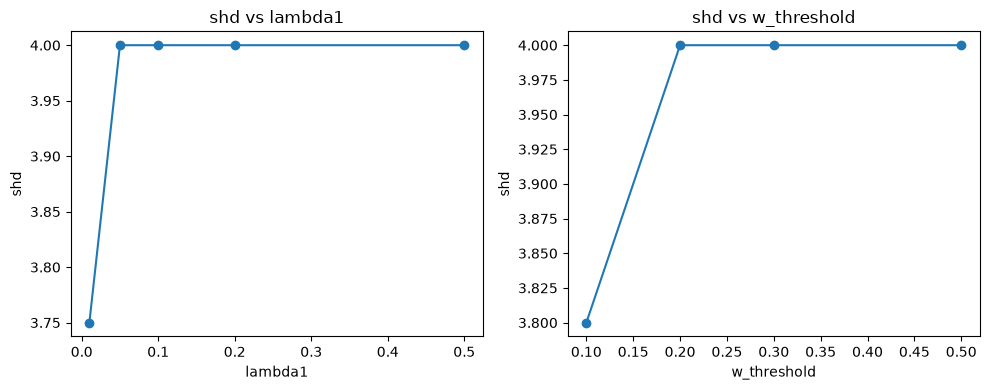

Top 5 combinations by shd
 lambda1  w_threshold  f1  precision  recall  shd  n_learned
    0.01          0.1 0.4        1.0    0.25    3          1
    0.01          0.2 0.0        0.0    0.00    4          0
    0.01          0.3 0.0        0.0    0.00    4          0
    0.01          0.5 0.0        0.0    0.00    4          0
    0.05          0.1 0.0        0.0    0.00    4          0

Recommended: lambda1=0.01, w_threshold=0.1
  F1=0.400  Precision=1.000  Recall=0.250  SHD=3


In [ ]:
NOTEARS_CANCER_PARAM_GRID = {
    "lambda1":     [0.01, 0.05, 0.1, 0.2, 0.5],
    "w_threshold": [0.1, 0.2, 0.3, 0.5],
}
search_and_report(cancer_df, cancer_dag, NOTEARS_CANCER_PARAM_GRID, "notears")

### PC

2026-06-29 10:07:01,690 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting


Grid: 1 × 6 × 4 = 24 combinations



2026-06-29 10:07:01,847 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-29 10:07:01,899 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-29 10:07:02,062 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-29 10:07:02,135 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-29 10:07:02,221 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discove

Best SHD: 2  params: {'ci_test': 'pearsonr', 'significance_level': 0.005, 'max_cond_vars': 2.0}
     ci_test  significance_level  max_cond_vars  n_learned  shd  precision  \
0   pearsonr               0.001            2.0          2    3   0.500000   
1   pearsonr               0.001            3.0          2    3   0.500000   
2   pearsonr               0.001            4.0          2    3   0.500000   
3   pearsonr               0.001            NaN          2    3   0.500000   
4   pearsonr               0.005            2.0          3    2   0.666667   
5   pearsonr               0.005            3.0          3    2   0.666667   
6   pearsonr               0.005            4.0          3    2   0.666667   
7   pearsonr               0.005            NaN          3    2   0.666667   
8   pearsonr               0.010            2.0          4    2   0.500000   
9   pearsonr               0.010            3.0          4    2   0.500000   
10  pearsonr               0.010            4.

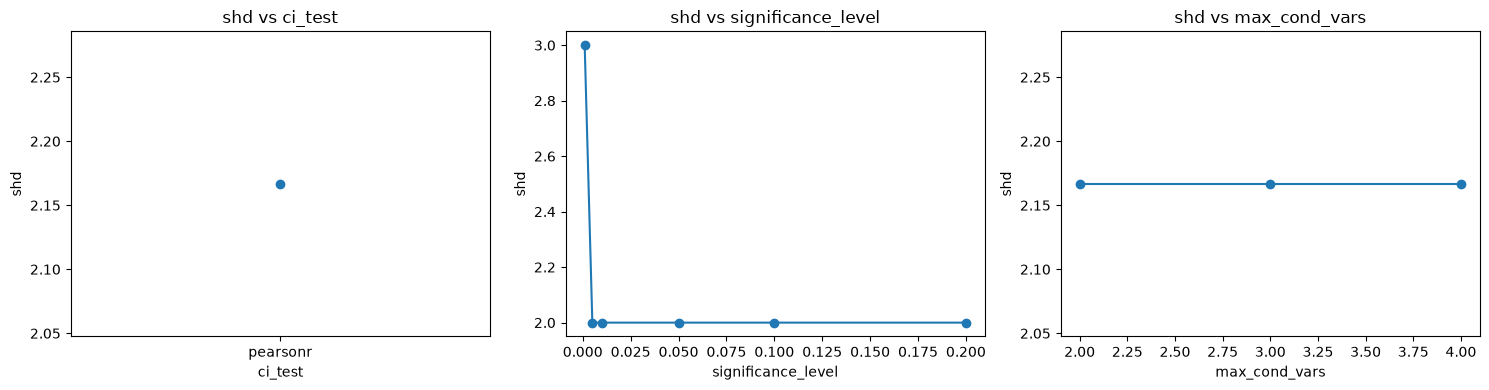

Top 5 combinations by shd
 ci_test  significance_level  max_cond_vars    f1  precision  recall  shd  n_learned
pearsonr               0.005            NaN 0.571      0.667     0.5    2          3
pearsonr               0.005            4.0 0.571      0.667     0.5    2          3
pearsonr               0.005            3.0 0.571      0.667     0.5    2          3
pearsonr               0.005            2.0 0.571      0.667     0.5    2          3
pearsonr               0.010            NaN 0.500      0.500     0.5    2          4

Recommended: ci_test=pearsonr, significance_level=0.005, max_cond_vars=nan
  F1=0.571  Precision=0.667  Recall=0.500  SHD=2


In [4]:
PC_CANCER_PARAM_GRID = {
    "ci_test":            ["pearsonr"],
    "significance_level": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "max_cond_vars":      [2, 3, 4, None],
}
search_and_report(cancer_df, cancer_dag, PC_CANCER_PARAM_GRID, "pc")

### FGES

Grid: 2 = 2 combinations

Best SHD: 1  params: {'method': 'scatter'}
    method  n_learned  shd  precision  recall        f1  tp  fp  fn  reversed
0  scatter          4    1   0.750000    0.75  0.750000   3   0   0         1
1       r2         11   13   0.090909    0.25  0.133333   1  10   3         0


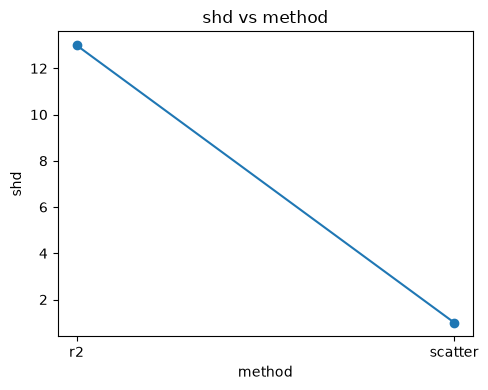

Top 5 combinations by shd
 method    f1  precision  recall  shd  n_learned
scatter 0.750      0.750    0.75    1          4
     r2 0.133      0.091    0.25   13         11

Recommended: method=scatter
  F1=0.750  Precision=0.750  Recall=0.750  SHD=1


In [5]:
FGES_CANCER_PARAM_GRID = {
    "method": ["scatter", "r2"],
}
search_and_report(cancer_df, cancer_dag, FGES_CANCER_PARAM_GRID, "fges")

### DAG-GNN

2026-06-30 20:43:47,447 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:165] - INFO: GPU is available.


Grid: 3 × 2 × 3 = 18 combinations



2026-06-30 20:43:53,533 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 0, epoch: 99, h_new: 0.0011701504513990102
2026-06-30 20:43:58,166 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 1, epoch: 99, h_new: 0.0011701504513990102
2026-06-30 20:44:15,986 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 2, epoch: 99, h_new: 0.00013298809749784368
2026-06-30 20:44:24,730 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 3, epoch: 99, h_new: 1.2808118670548652e-05
2026-06-30 20:44:33,779 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/ca

Best SHD: 4  params: {'mlp_dimension': 32.0, 'epochs': 100.0, 'lr': 0.0003}
    mlp_dimension  epochs      lr  n_learned  shd  precision  recall   f1  tp  \
0              32     100  0.0003          0    4        0.0     0.0  0.0   0   
1              32     100  0.0030          0    4        0.0     0.0  0.0   0   
2              32     100  0.0300          0    4        0.0     0.0  0.0   0   
3              32     300  0.0003          0    4        0.0     0.0  0.0   0   
4              32     300  0.0030          0    4        0.0     0.0  0.0   0   
5              32     300  0.0300          0    4        0.0     0.0  0.0   0   
6              64     100  0.0003          0    4        0.0     0.0  0.0   0   
7              64     100  0.0030          0    4        0.0     0.0  0.0   0   
8              64     100  0.0300          0    4        0.0     0.0  0.0   0   
9              64     300  0.0003          0    4        0.0     0.0  0.0   0   
10             64     300  0.0030

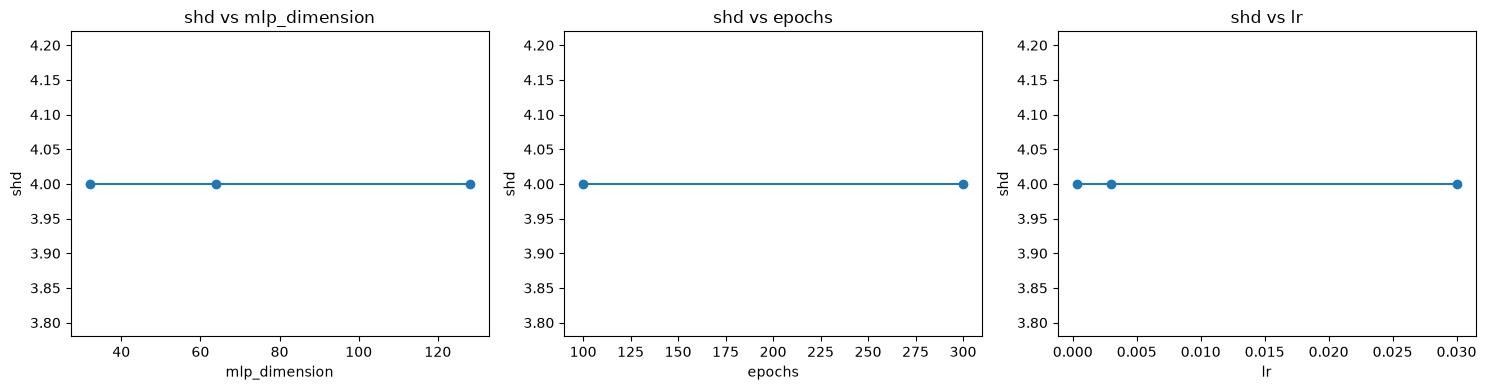

Top 5 combinations by shd
 mlp_dimension  epochs    lr  f1  precision  recall  shd  n_learned
            32     100 0.000 0.0        0.0     0.0    4          0
            32     100 0.003 0.0        0.0     0.0    4          0
            32     100 0.030 0.0        0.0     0.0    4          0
            32     300 0.000 0.0        0.0     0.0    4          0
            32     300 0.003 0.0        0.0     0.0    4          0

Recommended: mlp_dimension=32.0, epochs=100.0, lr=0.0003
  F1=0.000  Precision=0.000  Recall=0.000  SHD=4


In [4]:
DAGGNN_CANCER_PARAM_GRID = {
    "mlp_dimension":  [32, 64, 128],
    "epochs":          [100, 300],
    "lr": [0.0003, 0.003, 0.03],
}
search_and_report(cancer_df, cancer_dag, DAGGNN_CANCER_PARAM_GRID, "daggnn")

## Child

This section of the notebook contains hyper-parameter search for the Child dataset (20 variables)

In [8]:
child_df, child_dag = load_child(1000, SEED)
print(f"Child: {child_df.shape[0]} samples, {child_df.shape[1]} nodes, {len(child_dag.edges())} true edges")

Generating for node: ChestXray:   0%|          | 0/20 [00:00<?, ?it/s]  2026-07-01 19:04:44,024 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/utils/mathext.py[line:90] - WARNING: Probability values don't exactly sum to 1. Differ by: -2.220446049250313e-16. Adjusting values.
2026-07-01 19:04:44,024 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/utils/mathext.py[line:90] - WARNING: Probability values don't exactly sum to 1. Differ by: 2.220446049250313e-16. Adjusting values.
Generating for node: GruntingReport: 100%|██████████| 20/20 [00:00<00:00, 471.52it/s]

Child: 1000 samples, 20 nodes, 25 true edges


### NOTEARS

2026-06-29 11:31:23,455 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=10000, d=20, iter_=100, h_=1e-08, rho_=10000000000000000


Grid: 5 × 4 = 20 combinations



2026-06-29 11:31:25,296 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=2.756e-01, loss=7.381, rho=1.0e+00
2026-06-29 11:31:26,274 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.019e-01, loss=4.150, rho=1.0e+00
2026-06-29 11:31:27,652 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=9.765e-02, loss=4.492, rho=1.0e+01
2026-06-29 11:31:28,507 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=3.424e-02, loss=7.909, rho=1.0e+02
2026-06-29 11:31:30,974 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py

Best SHD: 21  params: {'lambda1': 0.01, 'w_threshold': 0.5}
    lambda1  w_threshold  n_learned  shd  precision  recall        f1  tp  fp  \
0      0.01          0.1         28   24   0.321429    0.36  0.339623   9   8   
1      0.01          0.2         26   22   0.346154    0.36  0.352941   9   6   
2      0.01          0.3         19   22   0.368421    0.28  0.318182   7   4   
3      0.01          0.5         14   21   0.357143    0.20  0.256410   5   1   
4      0.05          0.1         22   23   0.318182    0.28  0.297872   7   5   
5      0.05          0.2         19   23   0.315789    0.24  0.272727   6   4   
6      0.05          0.3         13   21   0.384615    0.20  0.263158   5   1   
7      0.05          0.5         10   22   0.400000    0.16  0.228571   4   1   
8      0.10          0.1         16   22   0.312500    0.20  0.243902   5   2   
9      0.10          0.2         11   22   0.363636    0.16  0.222222   4   1   
10     0.10          0.3         11   22   0.3636

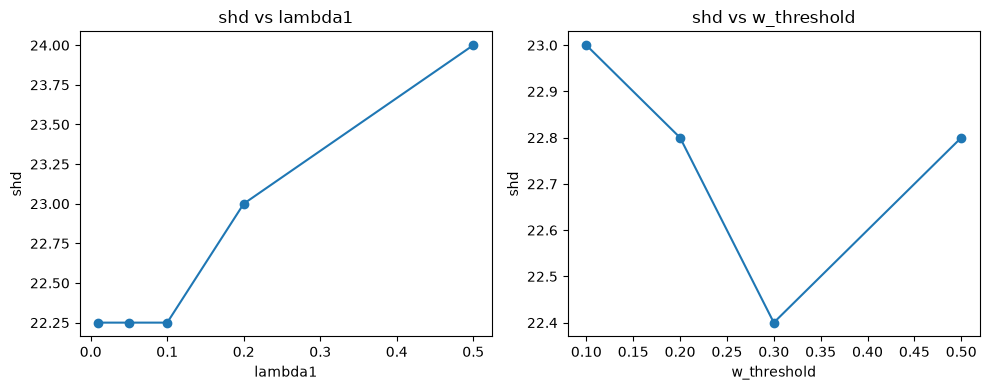

Top 5 combinations by shd
 lambda1  w_threshold    f1  precision  recall  shd  n_learned
    0.01          0.5 0.256      0.357    0.20   21         14
    0.05          0.3 0.263      0.385    0.20   21         13
    0.01          0.3 0.318      0.368    0.28   22         19
    0.01          0.2 0.353      0.346    0.36   22         26
    0.05          0.5 0.229      0.400    0.16   22         10

Recommended: lambda1=0.01, w_threshold=0.5
  F1=0.256  Precision=0.357  Recall=0.200  SHD=21


In [14]:
NOTEARS_CHILD_PARAM_GRID = {
    "lambda1":     [0.01, 0.05, 0.1, 0.2, 0.5],
    "w_threshold": [0.1, 0.2, 0.3, 0.5],
}
search_and_report(child_df, child_dag, NOTEARS_CHILD_PARAM_GRID, "notears")

### PC

Grid: 1 × 6 × 4 = 24 combinations



2026-06-29 11:01:40,961 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-29 11:01:43,914 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-29 11:01:47,073 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-29 11:01:50,373 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-06-29 11:01:53,588 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discove

Best SHD: 29  params: {'ci_test': 'pearsonr', 'significance_level': 0.05, 'max_cond_vars': 4.0}
     ci_test  significance_level  max_cond_vars  n_learned  shd  precision  \
0   pearsonr               0.001            2.0         37   33   0.270270   
1   pearsonr               0.001            3.0         37   33   0.270270   
2   pearsonr               0.001            4.0         37   33   0.270270   
3   pearsonr               0.001            NaN         37   33   0.270270   
4   pearsonr               0.005            2.0         37   32   0.297297   
5   pearsonr               0.005            3.0         37   32   0.297297   
6   pearsonr               0.005            4.0         37   32   0.297297   
7   pearsonr               0.005            NaN         37   32   0.297297   
8   pearsonr               0.010            2.0         36   32   0.277778   
9   pearsonr               0.010            3.0         35   31   0.285714   
10  pearsonr               0.010            4.

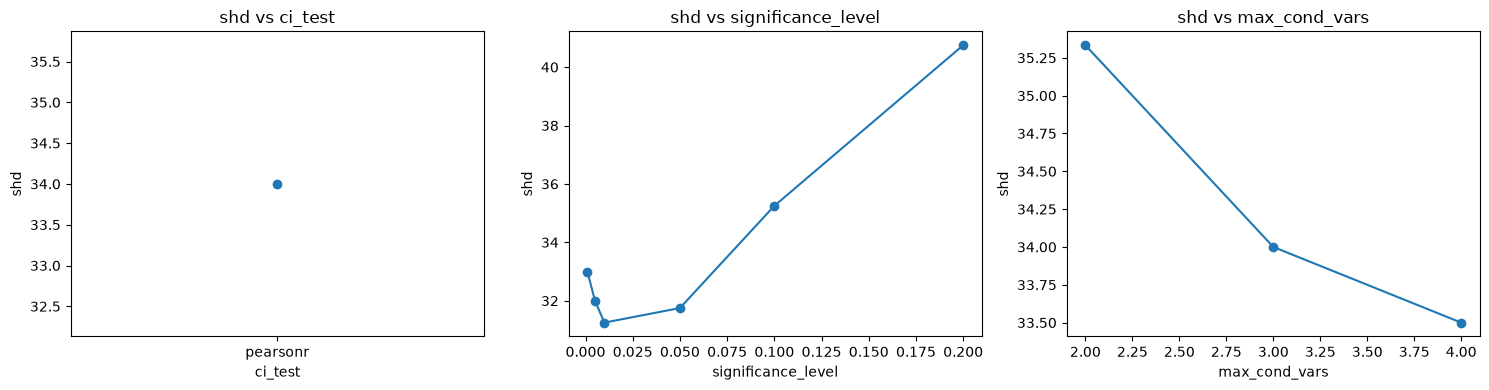

Top 5 combinations by shd
 ci_test  significance_level  max_cond_vars    f1  precision  recall  shd  n_learned
pearsonr                0.05            NaN 0.393      0.343   0.462   29         35
pearsonr                0.05            4.0 0.393      0.343   0.462   29         35
pearsonr                0.01            4.0 0.317      0.286   0.357   31         35
pearsonr                0.01            3.0 0.317      0.286   0.357   31         35
pearsonr                0.01            NaN 0.317      0.286   0.357   31         35

Recommended: ci_test=pearsonr, significance_level=0.05, max_cond_vars=nan
  F1=0.393  Precision=0.343  Recall=0.462  SHD=29


In [11]:
PC_CHILD_PARAM_GRID = {
    "ci_test":            ["pearsonr"],
    "significance_level": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "max_cond_vars":      [2, 3, 4, None],
}
search_and_report(child_df, child_dag, PC_CHILD_PARAM_GRID, "pc")

### FGES

Grid: 2 = 2 combinations

Best SHD: 36  params: {'method': 'scatter'}
    method  n_learned  shd  precision    recall        f1  tp  fp  fn  \
0  scatter         50   36   0.320000  0.592593  0.415584  16  25   2   
1       r2         47   64   0.042553  0.074074  0.054054   2  39  19   

   reversed  
0         9  
1         6  


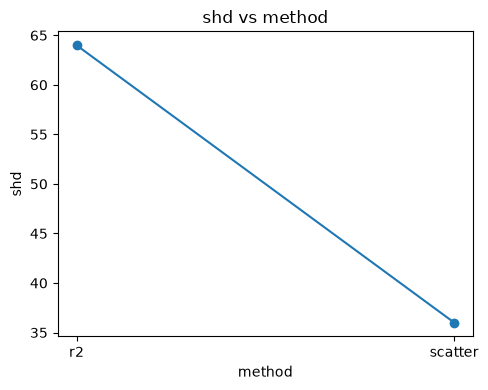

Top 5 combinations by shd
 method    f1  precision  recall  shd  n_learned
scatter 0.416      0.320   0.593   36         50
     r2 0.054      0.043   0.074   64         47

Recommended: method=scatter
  F1=0.416  Precision=0.320  Recall=0.593  SHD=36


In [12]:
FGES_CHILD_PARAM_GRID = {
    "method": ["scatter", "r2"],
}
search_and_report(child_df, child_dag, FGES_CHILD_PARAM_GRID, "fges")

### DAG-GNN

2026-07-01 19:05:35,859 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:165] - INFO: GPU is available.


Grid: 3 × 2 × 3 = 18 combinations



2026-07-01 19:05:40,590 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 0, epoch: 99, h_new: 0.044952160079553494
2026-07-01 19:05:49,649 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 1, epoch: 99, h_new: 0.007597901580513877
2026-07-01 19:05:58,279 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 2, epoch: 99, h_new: 0.0016712690645732664
2026-07-01 19:06:06,791 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 3, epoch: 99, h_new: 0.00035128634969439076
2026-07-01 19:06:16,069 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castl

Best SHD: 24  params: {'mlp_dimension': 32.0, 'epochs': 100.0, 'lr': 0.003}
    mlp_dimension  epochs      lr  n_learned  shd  precision  recall  \
0              32     100  0.0003         22   27   0.227273     0.2   
1              32     100  0.0030         17   24   0.294118     0.2   
2              32     100  0.0300          0   25   0.000000     0.0   
3              32     300  0.0003         19   26   0.263158     0.2   
4              32     300  0.0030         19   25   0.263158     0.2   
5              32     300  0.0300          0   25   0.000000     0.0   
6              64     100  0.0003         20   26   0.250000     0.2   
7              64     100  0.0030         19   26   0.263158     0.2   
8              64     100  0.0300          0   25   0.000000     0.0   
9              64     300  0.0003         20   26   0.250000     0.2   
10             64     300  0.0030         17   24   0.294118     0.2   
11             64     300  0.0300          0   25   0.000000

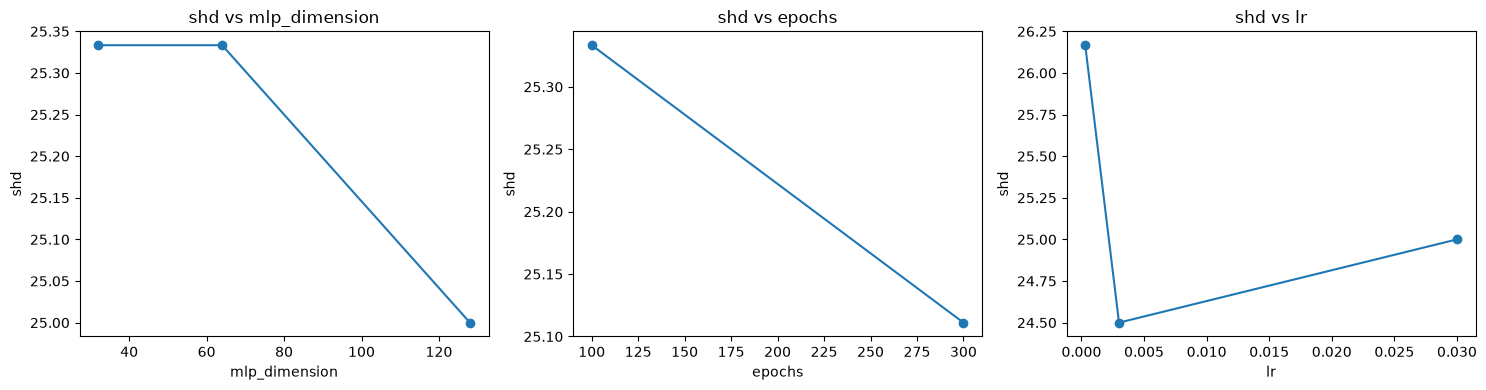

Top 5 combinations by shd
 mlp_dimension  epochs    lr    f1  precision  recall  shd  n_learned
            32     100 0.003 0.238      0.294     0.2   24         17
            64     300 0.003 0.238      0.294     0.2   24         17
           128     100 0.003 0.238      0.294     0.2   24         17
           128     300 0.003 0.238      0.294     0.2   24         17
            64     100 0.030 0.000      0.000     0.0   25          0

Recommended: mlp_dimension=32.0, epochs=100.0, lr=0.003
  F1=0.238  Precision=0.294  Recall=0.200  SHD=24


In [10]:
DAGGNN_CHILD_PARAM_GRID = {
    "mlp_dimension":  [32, 64, 128],
    "epochs":          [100, 300],
    "lr": [0.0003, 0.003, 0.03],
}
search_and_report(child_df, child_dag, DAGGNN_CHILD_PARAM_GRID, "daggnn")

## Alarm

This section of the notebook contains hyper-parameter search for the Alarm dataset (37 variables)

In [5]:
alarm_df, alarm_dag = load_alarm(1000, SEED)
print(f"Alarm: {alarm_df.shape[0]} samples, {alarm_df.shape[1]} nodes, {len(alarm_dag.edges())} true edges")

Generating for node: BP: 100%|██████████| 37/37 [00:00<00:00, 545.49it/s]

Alarm: 1000 samples, 37 nodes, 46 true edges


### NOTEARS

2026-07-03 21:41:23,859 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=37, iter_=100, h_=1e-08, rho_=10000000000000000


Grid: 5 × 4 = 20 combinations



2026-07-03 21:41:24,429 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=3.143e-01, loss=6.944, rho=1.0e+00
2026-07-03 21:41:24,802 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.102e-01, loss=3.352, rho=1.0e+00
2026-07-03 21:41:25,309 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=9.108e-02, loss=3.797, rho=1.0e+01
2026-07-03 21:41:25,753 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=3.008e-02, loss=8.242, rho=1.0e+02
2026-07-03 21:41:26,148 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py

Best SHD: 34  params: {'lambda1': 0.01, 'w_threshold': 0.2}
    lambda1  w_threshold  n_learned  shd  precision    recall        f1  tp  \
0      0.01          0.1         61   41   0.491803  0.652174  0.560748  30   
1      0.01          0.2         41   34   0.585366  0.521739  0.551724  24   
2      0.01          0.3         31   34   0.612903  0.413043  0.493506  19   
3      0.01          0.5         23   39   0.565217  0.282609  0.376812  13   
4      0.05          0.1         25   38   0.520000  0.282609  0.366197  13   
5      0.05          0.2         21   38   0.523810  0.239130  0.328358  11   
6      0.05          0.3         17   39   0.588235  0.217391  0.317460  10   
7      0.05          0.5         14   39   0.642857  0.195652  0.300000   9   
8      0.10          0.1         19   39   0.631579  0.260870  0.369231  12   
9      0.10          0.2         15   39   0.666667  0.217391  0.327869  10   
10     0.10          0.3         12   42   0.583333  0.152174  0.241379

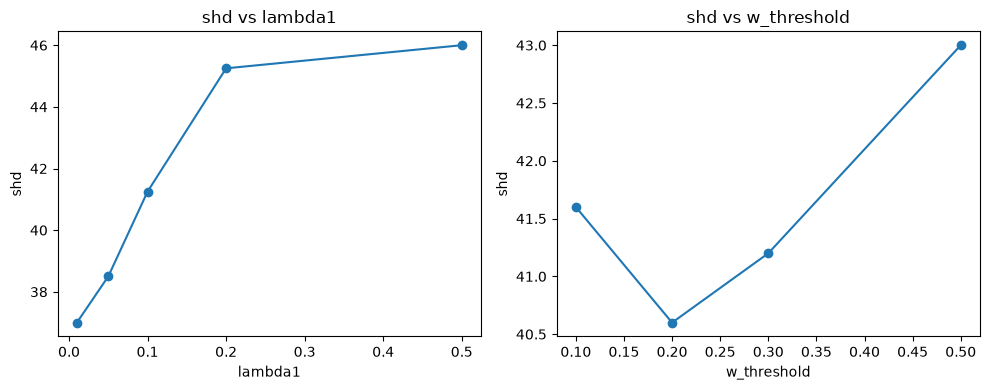

Top 5 combinations by shd
 lambda1  w_threshold    f1  precision  recall  shd  n_learned
    0.01          0.2 0.552      0.585   0.522   34         41
    0.01          0.3 0.494      0.613   0.413   34         31
    0.05          0.2 0.328      0.524   0.239   38         21
    0.05          0.1 0.366      0.520   0.283   38         25
    0.05          0.3 0.317      0.588   0.217   39         17

Recommended: lambda1=0.01, w_threshold=0.2
  F1=0.552  Precision=0.585  Recall=0.522  SHD=34


In [9]:
NOTEARS_BARLEY_PARAM_GRID = {
    "lambda1":     [0.01, 0.05, 0.1, 0.2, 0.5],
    "w_threshold": [0.1, 0.2, 0.3, 0.5],
}
search_and_report(alarm_df, alarm_dag, NOTEARS_BARLEY_PARAM_GRID, "notears")

### PC

Grid: 1 × 6 × 4 = 24 combinations



2026-07-03 21:27:47,967 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-03 21:27:51,241 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-03 21:27:54,496 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-03 21:28:01,925 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discovery/_base.py[line:417] - INFO: Reached maximum number of allowed conditional variables. Exiting
2026-07-03 21:28:06,312 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/causal_discove

Best SHD: 29  params: {'ci_test': 'pearsonr', 'significance_level': 0.01, 'max_cond_vars': 2.0}
     ci_test  significance_level  max_cond_vars  n_learned  shd  precision  \
0   pearsonr               0.001            2.0         46   35   0.543478   
1   pearsonr               0.001            3.0         46   35   0.543478   
2   pearsonr               0.001            4.0         46   35   0.543478   
3   pearsonr               0.001            NaN         46   35   0.543478   
4   pearsonr               0.005            2.0         46   31   0.608696   
5   pearsonr               0.005            3.0         46   31   0.608696   
6   pearsonr               0.005            4.0         46   31   0.608696   
7   pearsonr               0.005            NaN         46   31   0.608696   
8   pearsonr               0.010            2.0         48   29   0.645833   
9   pearsonr               0.010            3.0         48   29   0.645833   
10  pearsonr               0.010            4.

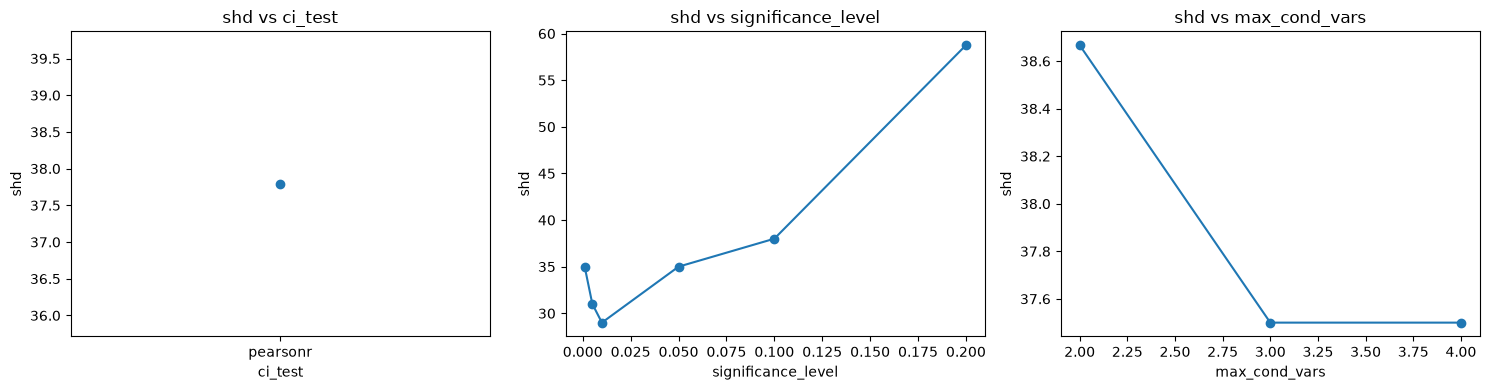

Top 5 combinations by shd
 ci_test  significance_level  max_cond_vars    f1  precision  recall  shd  n_learned
pearsonr               0.010            NaN 0.614      0.646   0.585   29         48
pearsonr               0.010            4.0 0.614      0.646   0.585   29         48
pearsonr               0.010            3.0 0.614      0.646   0.585   29         48
pearsonr               0.010            2.0 0.614      0.646   0.585   29         48
pearsonr               0.005            NaN 0.566      0.609   0.528   31         46

Recommended: ci_test=pearsonr, significance_level=0.01, max_cond_vars=nan
  F1=0.614  Precision=0.646  Recall=0.585  SHD=29


In [7]:
PC_BARLEY_PARAM_GRID = {
    "ci_test":            ["pearsonr"],
    "significance_level": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    "max_cond_vars":      [2, 3, 4, None],
}
search_and_report(alarm_df, alarm_dag, PC_BARLEY_PARAM_GRID, "pc")

### FGES

In [ ]:
FGES_BARLEY_PARAM_GRID = {
    "method": ["scatter", "r2"],
}
search_and_report(alarm_df, alarm_dag, FGES_BARLEY_PARAM_GRID, "fges")

Grid: 2 = 2 combinations



### DAG-GNN

2026-07-04 13:58:41,000 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:165] - INFO: GPU is available.


Grid: 3 × 2 × 3 = 18 combinations



2026-07-04 13:58:47,644 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 0, epoch: 99, h_new: 0.04826470978954944
2026-07-04 13:58:56,853 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 1, epoch: 99, h_new: 0.009264431429969022
2026-07-04 13:59:10,479 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 2, epoch: 99, h_new: 0.0007425114793164767
2026-07-04 13:59:19,524 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 3, epoch: 99, h_new: 0.00011608169192811602
2026-07-04 13:59:28,642 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle

Best SHD: 42  params: {'mlp_dimension': 32.0, 'epochs': 300.0, 'lr': 0.003}
    mlp_dimension  epochs      lr  n_learned  shd  precision    recall  \
0              32     100  0.0003         42   48   0.404762  0.369565   
1              32     100  0.0030         36   45   0.444444  0.347826   
2              32     100  0.0300          0   46   0.000000  0.000000   
3              32     300  0.0003         61   59   0.344262  0.456522   
4              32     300  0.0030         33   42   0.484848  0.347826   
5              32     300  0.0300          0   46   0.000000  0.000000   
6              64     100  0.0003         53   55   0.358491  0.413043   
7              64     100  0.0030         36   46   0.416667  0.326087   
8              64     100  0.0300          0   46   0.000000  0.000000   
9              64     300  0.0003         61   60   0.327869  0.434783   
10             64     300  0.0030         39   47   0.410256  0.347826   
11             64     300  0.0300   

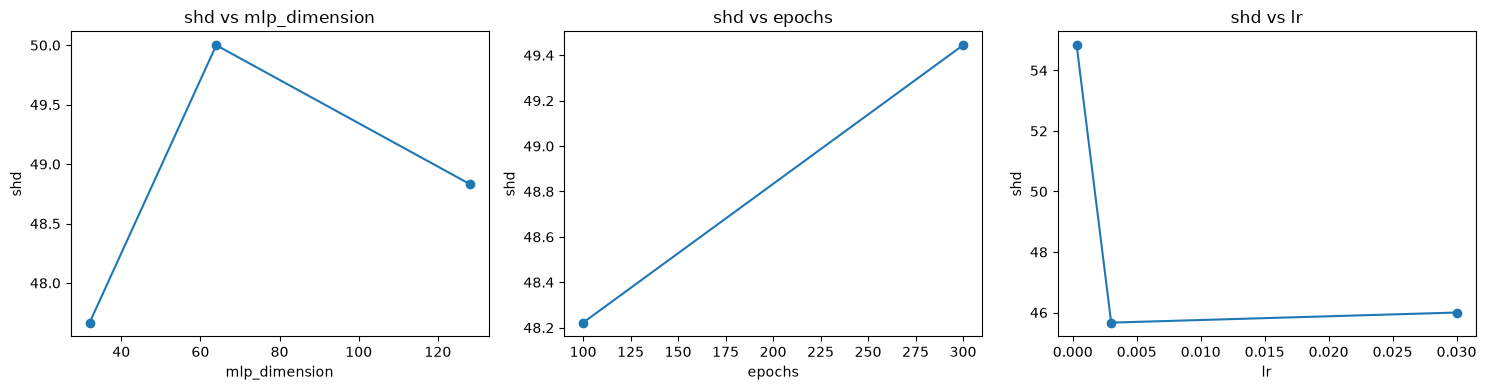

Top 5 combinations by shd
 mlp_dimension  epochs    lr    f1  precision  recall  shd  n_learned
            32     300 0.003 0.405      0.485   0.348   42         33
            32     100 0.003 0.390      0.444   0.348   45         36
           128     300 0.003 0.390      0.444   0.348   45         36
            32     300 0.030 0.000      0.000   0.000   46          0
            64     100 0.003 0.366      0.417   0.326   46         36

Recommended: mlp_dimension=32.0, epochs=300.0, lr=0.003
  F1=0.405  Precision=0.485  Recall=0.348  SHD=42


In [4]:
DAGGNN_BARLEY_PARAM_GRID = {
    "mlp_dimension":  [32, 64, 128],
    "epochs":          [100, 300],
    "lr": [0.0003, 0.003, 0.03],
}
search_and_report(alarm_df, alarm_dag, DAGGNN_BARLEY_PARAM_GRID, "daggnn")